In [1]:
#import the necessary libraries
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os

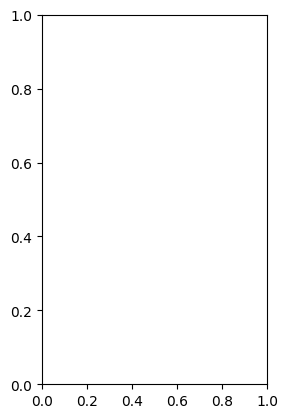

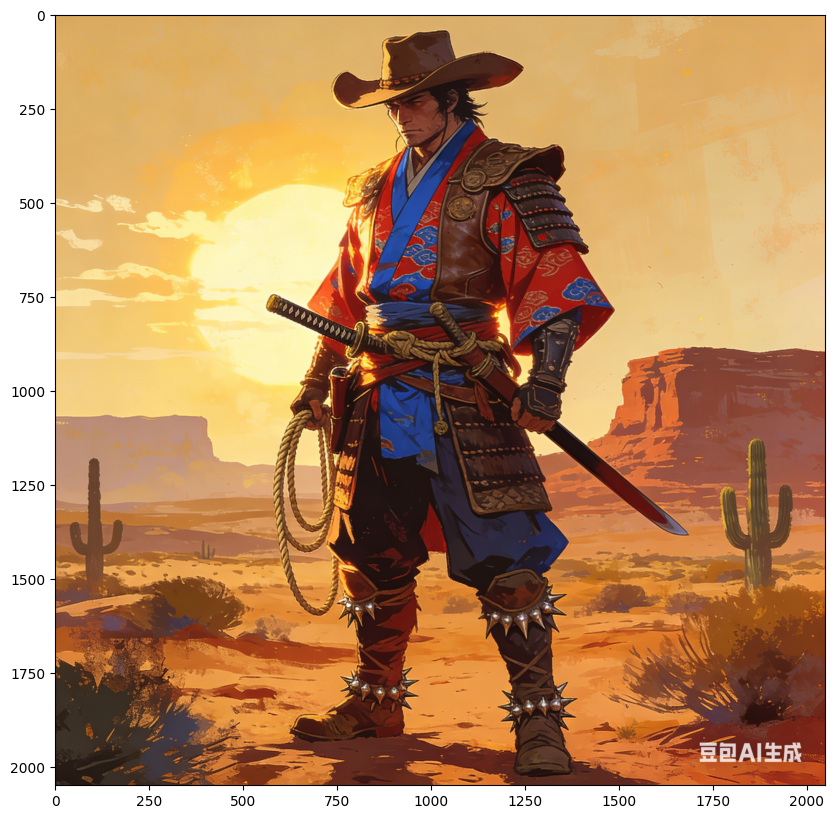

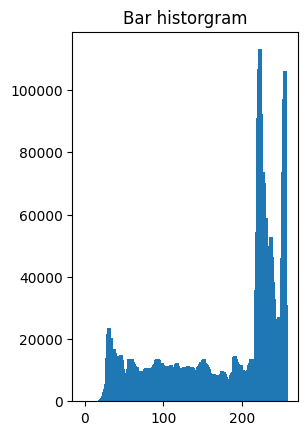

In [2]:
pic = "2.png"
pic_path = "images"
route = os.path.join(pic_path, pic)
original_image = cv2.imread(route)
rgb_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

plt.subplot(1,2,1)
plt.figure(figsize=(10,10))
plt.imshow(rgb_image)
plt.show()

hist = cv2.calcHist([rgb_image],[0],None,[256],[0,256])
hist.shape
intensity = np.array([x for x in range(hist.shape[0])])
plt.subplot(1,2,2)
plt.bar(intensity, hist[:,0], width = 5)
plt.title("Bar historgram")
plt.show()


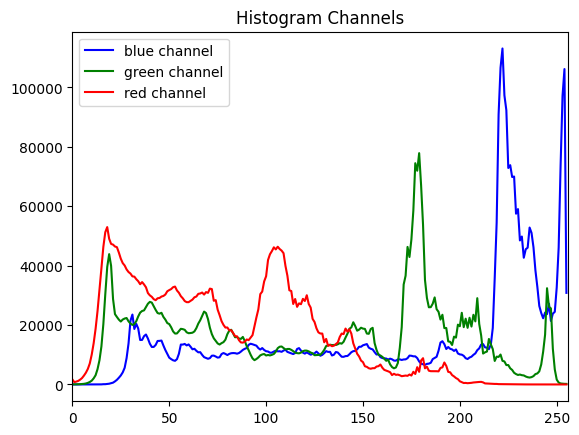

In [3]:
color = ('blue','green','red')
for i,col in enumerate(color):
    histr = cv2.calcHist([rgb_image],[i],None,[256],[0,256])
    plt.plot(intensity, histr, color = col, label = col+" channel")
    plt.xlim([0,256])
plt.legend()
plt.title("Histogram Channels")
plt.show()

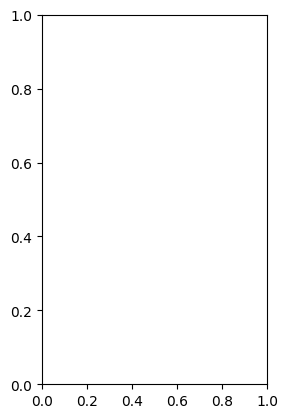

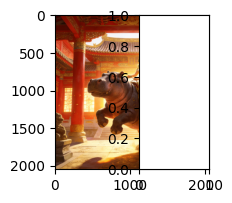

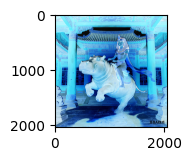

In [4]:
path = "images"
pic = '3.png'
route = os.path.join(path, pic)
image = cv2.imread(route)
pic_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.subplot(1,2,1)
plt.figure(figsize=(2,2))
plt.axis = ("off")
plt.imshow(pic_rgb)

img_neg = (255 - pic_rgb.astype(np.float32)).clip(0, 255).astype(np.uint8)

plt.subplot(1,2,2)
plt.figure(figsize=(2,2))
plt.axis = ("off")
plt.imshow(img_neg)
plt.tight_layout()
plt.show()

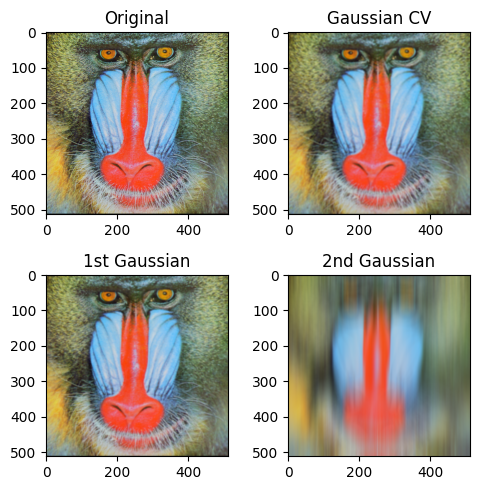

In [9]:
path = "images"
image = "baboon.png"
route = os.path.join(path, image)
image_bgr = cv2.imread(route)
image_grey = cv2.imread(route, cv2.IMREAD_GRAYSCALE)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

#Define filters
mean_kernel = np.ones((21,21), np.float32)/25
gaussian_kernel = cv2.getGaussianKernel(5, 1.5)
gaussian_kernel_2d = gaussian_kernel @ gaussian_kernel.T

gaussian_kernel_1 = cv2.getGaussianKernel(5, 2.5)
gaussian_kernel_1_2d = gaussian_kernel_1 @ gaussian_kernel.T

gaussian_kernel_2 = cv2.getGaussianKernel(100, 50)
gaussian_kernel_2_2d = gaussian_kernel_2 @ gaussian_kernel.T

sobel_x_kernel = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], np.float32)

#apply filter
mean_blur = cv2.filter2D(image_rgb, -1, mean_kernel)
gaussian_blur0 = cv2.GaussianBlur(image_rgb, (5,5), 15)
gaussian_blur_1 = cv2.filter2D(image_rgb, -1, gaussian_kernel_2d)
gaussian_blur_2 = cv2.filter2D(image_rgb, -1, gaussian_kernel_1_2d)
gaussian_blur_3 = cv2.filter2D(image_rgb, -1, gaussian_kernel_2_2d)
sobel_x = cv2.filter2D(image_rgb, -1, sobel_x_kernel)

plt.figure(figsize=(5,5))
plt.subplot(2,2,1)
plt.imshow(image_rgb)
plt.title("Original")
#plt.axis('off')
plt.subplot(2,2,2)
plt.imshow(gaussian_blur0)
plt.title('Gaussian CV')
#plt.axis('off')
plt.subplot(2,2,3)
plt.imshow(gaussian_blur_1)
plt.title('1st Gaussian')
plt.subplot(2,2,4)
plt.imshow(gaussian_blur_3)
plt.title('2nd Gaussian')
plt.tight_layout()
plt.show()
